In [4]:
# ==================== FUNCTION DEFINITION =====================

### Function 1 to split the box, if it is too big (max. 2500px): ###
def split_bbox(bbox, max_width, max_height, resolution):
    from shapely.geometry import box
    from sentinelhub import BBox, CRS

    bbox_geom = box(*bbox)
    minx, miny, maxx, maxy = bbox

    width_m = maxx - minx
    height_m = maxy - miny

    tile_width = resolution * max_width
    tile_height = resolution * max_height

    tiles = []
    y = miny
    while y < maxy:
        x = minx
        while x < maxx:
            tile_maxx = min(x + tile_width, maxx)
            tile_maxy = min(y + tile_height, maxy)
            tile = BBox([x, y, tile_maxx, tile_maxy], crs=CRS(32632))
            tiles.append(tile)
            x += tile_width
        y += tile_height
    return tiles

### Function 2 to download the FSC data from copernicus browser API ###
# define variables
def process_fsc_data(coords: [float, float, float, float],
                     selected_dates: list,
                     output_folder: str,
                     time_interval: [str, str],
                     eval_fsc_scl_mask,
                     glacier_shp: str,
                     lake_shp: str,
                     forest_mask_path: str,
                     resolution,
                     tile_cloud_cover,
                     max_nodata_fraction):
    # import utilities
    import os
    import shutil
    from pathlib import Path
    from datetime import datetime, timedelta

    import numpy as np
    import pandas as pd
    import geopandas as gpd
    import rioxarray as rxr
    import xarray as xr
    import re

    from rasterio.features import rasterize
    from sentinelhub import (
        SHConfig, DataCollection, SentinelHubCatalog, SentinelHubRequest,
        MimeType, BBox, bbox_to_dimensions, CRS
    )
    
    # set up the connection!
    config = SHConfig("MO_v2")
    if not config.sh_client_id or not config.sh_client_secret:
        raise RuntimeError("SentinelHub credentials missing!", "\n")
    else: 
        print("Successfully connected to Copenicus API", "\n")
    
    # set crs, bbox
    epsg = 32632
    aoi_bbox = BBox(bbox=coords, crs=CRS(epsg))
    aoi_size = bbox_to_dimensions(aoi_bbox, resolution=resolution)
    print(f"Image shape at {resolution} m resolution: {aoi_size} pixels")

    # Check if size exceeds 2500x2500
    if aoi_size[0] > 2500 or aoi_size[1] > 2500:
        print("AOI exceeds max size, splitting into tiles...")
        tile_bboxes = split_bbox(coords, max_width=2500, max_height=2500, resolution=resolution)
    else:
        tile_bboxes = [aoi_bbox]

    # Print the sizes of the tiles
    for i, tile in enumerate(tile_bboxes):
        tile_size = bbox_to_dimensions(tile, resolution=resolution)
        print(f"Tile {i}: {tile_size[0]} x {tile_size[1]} pixels")
        
    print("\n")
    
    catalog = SentinelHubCatalog(config=config)
    search_iterator = catalog.search(
        DataCollection.SENTINEL2_L2A,
        bbox=aoi_bbox,
        time=time_interval,
        fields={"include": ["id", "properties.datetime"], "exclude": []},
        filter=f"eo:cloud_cover < {tile_cloud_cover}"
    )

    results = list(search_iterator)
    # print(f"Total tiles found: {len(results)}")

    datetime_list = sorted({datetime.strptime(result["properties"]["datetime"][:10], '%Y-%m-%d') for result in results})
    print(f"Available dates found with cloud cover < {tile_cloud_cover}: {len(datetime_list)}")

    # print available dates
    print("Available dates:", ', '.join(d.strftime("%Y-%m-%d") for d in datetime_list), "\n")

    # Download images
    ndsi_images = []
    for current_date in datetime_list:
        time_interval_day = (current_date.strftime("%Y-%m-%d"), current_date.strftime("%Y-%m-%d"))
        print(f"Downloading image for: {time_interval_day[0]}")

        for i, tile in enumerate(tile_bboxes):
            print(f"           Tile {i}")
            tile_size = bbox_to_dimensions(tile, resolution=resolution)
            tile_folder = os.path.join(output_folder, f"{time_interval_day[0]}_tile_{i}")

            request_ndsi = SentinelHubRequest(
                data_folder=tile_folder,
                evalscript=eval_fsc_scl_mask,
                input_data=[
                    SentinelHubRequest.input_data(
                        data_collection=DataCollection.SENTINEL2_L2A.define_from("s2l2a", service_url=config.sh_base_url),
                        time_interval=time_interval_day
                    )
                ],
                responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
                bbox=tile,
                size=tile_size,
                config=config,
            )
            ndsi_imgs = request_ndsi.get_data(save_data=True)
            ndsi_images.extend(ndsi_imgs)


    # Function 2.1 Reorganize folder structure
    def process_tiff_files(base_path, resolution):
        from collections import defaultdict
        import rioxarray as rxr
        import xarray as xr
        import shutil
        from pathlib import Path
        import rasterio
        from rasterio.merge import merge as rio_merge
        import numpy as np

        base_path = Path(base_path)
        date_tile_groups = defaultdict(list)

        # Step 1: Reorganize and collect tile files
        for date_folder in base_path.iterdir():
            if date_folder.is_dir():
                nested = list(date_folder.glob("*/response.tiff"))
                if len(nested) == 1:
                    tile_id = date_folder.name.split('_tile_')[-1]
                    date_part = date_folder.name.split('_tile_')[0]
                    new_name = f"ndsi_{date_part}_tile_{tile_id}.tiff"
                    target_path = base_path / new_name
                    shutil.move(str(nested[0]), target_path)
                    shutil.rmtree(date_folder)
                    # print(f"Moved and renamed {new_name}")
                    date_tile_groups[date_part].append(target_path)

        print("\n","Folder structure reorganized. Next merging tiles to one single file and filtering if very high cloud cover...", "\n")

        # Step 2: Merge tiles per date
        for date, file_list in date_tile_groups.items():
            src_files_to_mosaic = [rasterio.open(fp) for fp in file_list]

            # Merge them using rasterio
            mosaic, out_transform = rio_merge(src_files_to_mosaic)

            # Check for NaN coverage using xarray
            temp_da = xr.DataArray(
                mosaic.squeeze(),
                dims=["y", "x"],
                attrs={"transform": out_transform}
            )
            nan_ratio = np.isnan(temp_da.values).sum() / temp_da.size

            # Close files before deleting if needed
            for src in src_files_to_mosaic:
                src.close()

            if nan_ratio > max_nodata_fraction:
                print(f"Image of {date} deleted — too many NaNs: {nan_ratio:.2%}")
                for fp in file_list:
                    fp.unlink()
                continue  # Skip saving

            # Proceed to write the merged mosaic
            out_meta = src_files_to_mosaic[0].meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": mosaic.shape[1],
                "width": mosaic.shape[2],
                "transform": out_transform
            })

            out_path = base_path / f"ndsi_{date}.tiff"
            with rasterio.open(out_path, "w", **out_meta) as dest:
                dest.write(mosaic)

            # print(f"Merged and saved: {out_path.name}")

            # Remove tile files
            for fp in file_list:
                fp.unlink()

        print("\n","All tiles merged per date to one file.")
    
    process_tiff_files(output_folder, resolution=resolution)

    # Combine datasets
    pattern = re.compile(r"ndsi_(\d{4}-\d{2}-\d{2})\.tiff")
    datasets = []
    for file in os.listdir(output_folder):
        if pattern.match(file):
            date_str = pattern.match(file).group(1)
            date = pd.to_datetime(date_str).date()
            dataset = rxr.open_rasterio(os.path.join(output_folder, file)).expand_dims(time=[pd.Timestamp(date)])
            datasets.append(dataset)

    if not datasets:
        print("No datasets found!")
        return

    combined_dataset = xr.concat(datasets, dim="time")
    combined_dataset.rio.write_nodata(np.nan, inplace=True)

    # # Filter based on NaN coverage fILTER APPLIED DIRECTLY WHEN DOWNLOADING!!
    # nan_fraction = combined_dataset.isnull().sum(dim=["x", "y"]) / (combined_dataset.sizes["x"] * combined_dataset.sizes["y"])
    # valid_indices = (nan_fraction <= max_nodata_fraction).values.flatten()
    # num_before = combined_dataset.sizes["time"]
    # combined_dataset = combined_dataset.isel(time=valid_indices)
    # num_after = combined_dataset.sizes["time"]

    # print(f"Datasets filtered to exclude very high cloud cover. Removed {num_before - num_after} of {num_before} images due to excessive cloud cover.\n")

    # Prepare folders
    selected_dir = os.path.join(output_folder, "selected")
    masked_dir = os.path.join(output_folder, "selected_masked")
    os.makedirs(masked_dir, exist_ok=True)

    if selected_dates:
        os.makedirs(selected_dir, exist_ok=True)
        selected_date_strs = set(dt.strftime("%Y-%m-%d") for dt in selected_dates)

        for file in os.listdir(output_folder):
            if file.startswith("ndsi_") and file.endswith(".tiff"):
                if file[5:-5] in selected_date_strs:
                    shutil.copy2(os.path.join(output_folder, file), os.path.join(selected_dir, file))
                    print(f"Copied {file} to selected folder")

        files_to_mask = [f for f in os.listdir(selected_dir) if f.endswith(".tiff") and f.startswith("ndsi_")]
    else:
        print("No selected dates provided. Skipping selection. Masking all available images.\n")
        files_to_mask = [f for f in os.listdir(output_folder) if f.endswith(".tiff") and f.startswith("ndsi_")]

    # Load mask data
    glacier_gdf = gpd.read_file(glacier_shp)
    lake_gdf = gpd.read_file(lake_shp)
    forest_mask = rxr.open_rasterio(forest_mask_path).squeeze()

    # Apply masks
    for file in files_to_mask:
        img_path = os.path.join(selected_dir if selected_dates else output_folder, file)
        img = rxr.open_rasterio(img_path).squeeze()
        forest_mask_matched = forest_mask.rio.reproject_match(img)

        glacier_mask = rasterize(
            [(geom, 1) for geom in glacier_gdf.to_crs(img.rio.crs).geometry],
            out_shape=img.shape,
            transform=img.rio.transform(),
            fill=0,
            dtype="uint8"
        )

        lake_mask = rasterize(
            [(geom, 1) for geom in lake_gdf.to_crs(img.rio.crs).geometry],
            out_shape=img.shape,
            transform=img.rio.transform(),
            fill=0,
            dtype="uint8"
        )

        combined_mask = (forest_mask_matched.values == 1) | (glacier_mask == 1) | (lake_mask == 1)
        masked_img = img.where(~combined_mask)

        masked_img.rio.to_raster(os.path.join(masked_dir, file))
        # print(f"Masked and saved: {file}")
    print("All files masked and saved!","\n","\n","saving the plot with all images...")

    # ------------------------------------------------------------------------------
    # Plot the "selected_masked" images as a grid, similar to previous plots
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib import cm
    import matplotlib.patches as mpatches
    import os
    import pandas as pd
    import geopandas as gpd
    import rioxarray as rxr
    import numpy as np
    import re
    import xarray as xr
    from pathlib import Path

    # output_folder=r"D:\FSC_results\ziller"
    noforest_dir = os.path.join(output_folder, "selected_masked")
    selected_masked_pattern = re.compile(r"ndsi_(\d{4}-\d{2}-\d{2})\.tiff")
    selected_masked_datasets = []

    for file in os.listdir(noforest_dir):  # noforest_dir now contains the new masked files (forest, glacier, lake)
        match = selected_masked_pattern.match(file)
        if match:
            date_str = match.group(1)
            date = pd.to_datetime(date_str).date()
            file_path = os.path.join(noforest_dir, file)
            ds = rxr.open_rasterio(file_path)
            if "time" not in ds.dims:
                ds = ds.expand_dims(time=[pd.Timestamp(date)])
            selected_masked_datasets.append(ds)

    if selected_masked_datasets:
        selected_masked_combined = xr.concat(selected_masked_datasets, dim="time")
        selected_masked_combined.rio.write_nodata(np.nan, inplace=True)
    else:
        print("No selected masked NDSI TIFF files found.")

    n_selected_masked = len(selected_masked_combined.time)
    nrows_masked = 4
    ncols_masked = int(np.ceil(n_selected_masked / nrows_masked))

    cmap_masked = cm.get_cmap("winter_r").copy()
    cmap_masked.set_bad(color="red")

    fig_masked, axes_masked = plt.subplots(nrows=nrows_masked, ncols=ncols_masked, figsize=(4*ncols_masked, 4*nrows_masked))
    axes_masked = axes_masked.flatten()

    for i in range(n_selected_masked):
        ax = axes_masked[i]
        img = np.ma.masked_invalid(selected_masked_combined[i, 0, :, :])
        im = ax.imshow(img, vmin=0, vmax=1, cmap=cmap_masked)
        ax.set_title(f"{str(selected_masked_combined.time.values[i])[:10]}")
        ax.axis("off")

    for j in range(n_selected_masked, len(axes_masked)):
        axes_masked[j].axis("off")

    fig_masked.subplots_adjust(right=0.85)
    cbar_ax_masked = fig_masked.add_axes([0.88, 0.15, 0.03, 0.7])
    fig_masked.colorbar(im, cax=cbar_ax_masked, label="FSC")

    red_patch_masked = mpatches.Patch(color='red', label='Clouds/Forest/Glacier/Lake')
    fig_masked.legend(handles=[red_patch_masked], loc='lower right', bbox_to_anchor=(0.98, 0.02))

    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plot_output_path = Path(output_folder) / "plots" / "selected_masked_images.png"
    plt.savefig(plot_output_path, dpi=300, bbox_inches="tight")
    # plt.show()
    
    print("Plot saved successfully and PROCESSING FINISHED!")

In [2]:
# define coordinates for the bbox
coords_achensee=(688675, 5250625, 710875, 5274625)
coords_kuehtai=(645975, 5204025, 673175, 5234725)
coords_kaunertal=(618775, 5187025, 646775, 5213325)

coords_engadin=(550975, 5131625,  613475, 5198125)
coords_ziller=(676275, 5205325, 738375, 5260925)
coords_nordost=(688675, 5239325, 749975, 5286925)
coords_zentral=(583375, 5180625,  701875, 5249625)

# Define all selected dates per AOI and season
from datetime import datetime

selected_dates_kuehtai_22_23 = [
    datetime(2022, 10, 3), datetime(2022, 10, 28), datetime(2023, 3, 22),
    datetime(2023, 6, 7), datetime(2023, 6, 20), datetime(2023, 6, 25),
    datetime(2023, 7, 15), datetime(2023, 8, 11)
]

selected_dates_kuehtai_23_24 = [
    datetime(2023, 10, 13), datetime(2023, 10, 28), datetime(2024, 2, 5),
    datetime(2024, 3, 11), datetime(2024, 4, 12), datetime(2024, 5, 20),
    datetime(2024, 6, 19), datetime(2024, 6, 29), datetime(2024, 7, 9),
    datetime(2024, 7, 14), datetime(2024, 8, 10)
]

selected_dates_kaunertal_22_23 = [
    datetime(2022, 10, 3), datetime(2022, 10, 28), datetime(2023, 3, 22),
    datetime(2023, 5, 3), datetime(2023, 6, 7), datetime(2023, 6, 25),
    datetime(2023, 7, 15), datetime(2023, 8, 11)
]

selected_dates_kaunertal_23_24 = [
    datetime(2023, 10, 25), datetime(2023, 10, 28), datetime(2024, 2, 5),
    datetime(2024, 3, 11), datetime(2024, 4, 12), datetime(2024, 5, 20),
    datetime(2024, 6, 19), datetime(2024, 6, 29), datetime(2024, 7, 9),
    datetime(2024, 7, 14), datetime(2024, 8, 10)
]

selected_dates_achensee_22_23 = [
    datetime(2022, 11, 9), datetime(2022, 11, 27), datetime(2023, 1, 1),
    datetime(2023, 2, 10), datetime(2023, 2, 15), datetime(2023, 2, 22),
    datetime(2023, 3, 7), datetime(2023, 3, 22), datetime(2023, 4, 21)
]

selected_dates_achensee_23_24 = [
    datetime(2023, 11, 4), datetime(2023, 12, 27), datetime(2024, 1, 3),
    datetime(2024, 2, 15), datetime(2024, 3, 8), datetime(2024, 4, 7),
    datetime(2024, 4, 27), datetime(2024, 4, 30)
]

# define the eval script
eval_fsc_scl_mask = """
//VERSION=3
function setup() {
  return {
    input: ["B03", "B11", "SCL"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

function evaluatePixel(sample) {
  let ndsi = (sample.B03 - sample.B11) / (sample.B03 + sample.B11);
  let image_mask = sample.SCL;

  // Mask values: adjust as needed
  let mask_values = [1,6,8,9];

  // FSC thresholds
  let ndsi_min = 0.1;
  let ndsi_max = 0.6;

  // Calculate FSC
  let fsc = 0.0;
  if (ndsi <= ndsi_min) {
    fsc = 0.0;
  } else if (ndsi >= ndsi_max) {
    fsc = 1.0;
  } else {
    fsc = (ndsi - ndsi_min) / (ndsi_max - ndsi_min);
  }

  // Mask out unwanted pixels
  let fsc_masked = mask_values.includes(image_mask) ? NaN : fsc;

  return [fsc_masked];
}
"""

In [15]:
# Example use for ziller 2018-2019
process_fsc_data(
    coords= coords_ziller,
    resolution=20,
    tile_cloud_cover = 40,
    max_nodata_fraction = 0.5,
    selected_dates= [],
    output_folder=r"D:\FSC_results\ziller",
    time_interval=("2018-10-01", "2019-10-01"),
    eval_fsc_scl_mask=eval_fsc_scl_mask,
    glacier_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\GI_5\Gletscher_AOIs.shp",
    lake_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\Seen_AOIs.shp",
    forest_mask_path = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\ses_topo_22_forest_mask_domain_epsg32632.tif"
    )

Successfully connected to Copenicus API 

Image shape at 20 m resolution: (3105, 2780) pixels
AOI exceeds max size, splitting into tiles...
Tile 0: 2500 x 2500 pixels
Tile 1: 605 x 2500 pixels
Tile 2: 2500 x 280 pixels
Tile 3: 605 x 280 pixels


Available dates found with cloud cover < 40: 65
Available dates: 2018-10-04, 2018-10-09, 2018-10-11, 2018-10-16, 2018-10-19, 2018-10-26, 2018-11-05, 2018-11-08, 2018-11-10, 2018-11-15, 2018-11-18, 2018-11-20, 2018-11-28, 2018-12-03, 2018-12-08, 2018-12-13, 2018-12-15, 2018-12-18, 2018-12-28, 2019-01-17, 2019-01-22, 2019-01-24, 2019-02-06, 2019-02-08, 2019-02-13, 2019-02-16, 2019-02-18, 2019-02-21, 2019-02-23, 2019-02-26, 2019-02-28, 2019-03-03, 2019-03-05, 2019-03-20, 2019-03-23, 2019-03-28, 2019-03-30, 2019-04-02, 2019-04-07, 2019-04-17, 2019-04-19, 2019-04-22, 2019-05-02, 2019-05-07, 2019-05-24, 2019-06-01, 2019-06-03, 2019-06-11, 2019-06-13, 2019-06-18, 2019-06-26, 2019-06-28, 2019-07-06, 2019-07-16, 2019-07-23, 2019-08-27, 2019-08-30, 2019-

Successfully connected to Copenicus API 

Image shape at 20 m resolution: (3125, 3325) pixels
AOI exceeds max size, splitting into tiles...
Tile 0: 2500 x 2500 pixels
Tile 1: 625 x 2500 pixels
Tile 2: 2500 x 825 pixels
Tile 3: 625 x 825 pixels


Available dates found with cloud cover < 50: 3
Available dates: 2018-10-04, 2018-10-09, 2018-10-11 

           Tile 0
           Tile 1
           Tile 2
           Tile 3
           Tile 0
           Tile 1
           Tile 2
           Tile 3
           Tile 0
           Tile 1
           Tile 2
           Tile 3

 Folder structure reorganized. Next merging tiles to one single file and filtering if very high cloud cover... 

Image of 2018-10-11 deleted — too many NaNs: 97.74%

 All tiles merged per date to one file.
No selected dates provided. Skipping selection. Masking all available images.

All files masked and saved! 
 
 saving the plot with all images...


C:\Users\Moritz\AppData\Local\Temp\ipykernel_21652\236882980.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_masked = cm.get_cmap("winter_r").copy()
C:\Users\Moritz\AppData\Local\Temp\ipykernel_21652\236882980.py:358: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


Plot saved successfully and PROCESSING FINISHED!


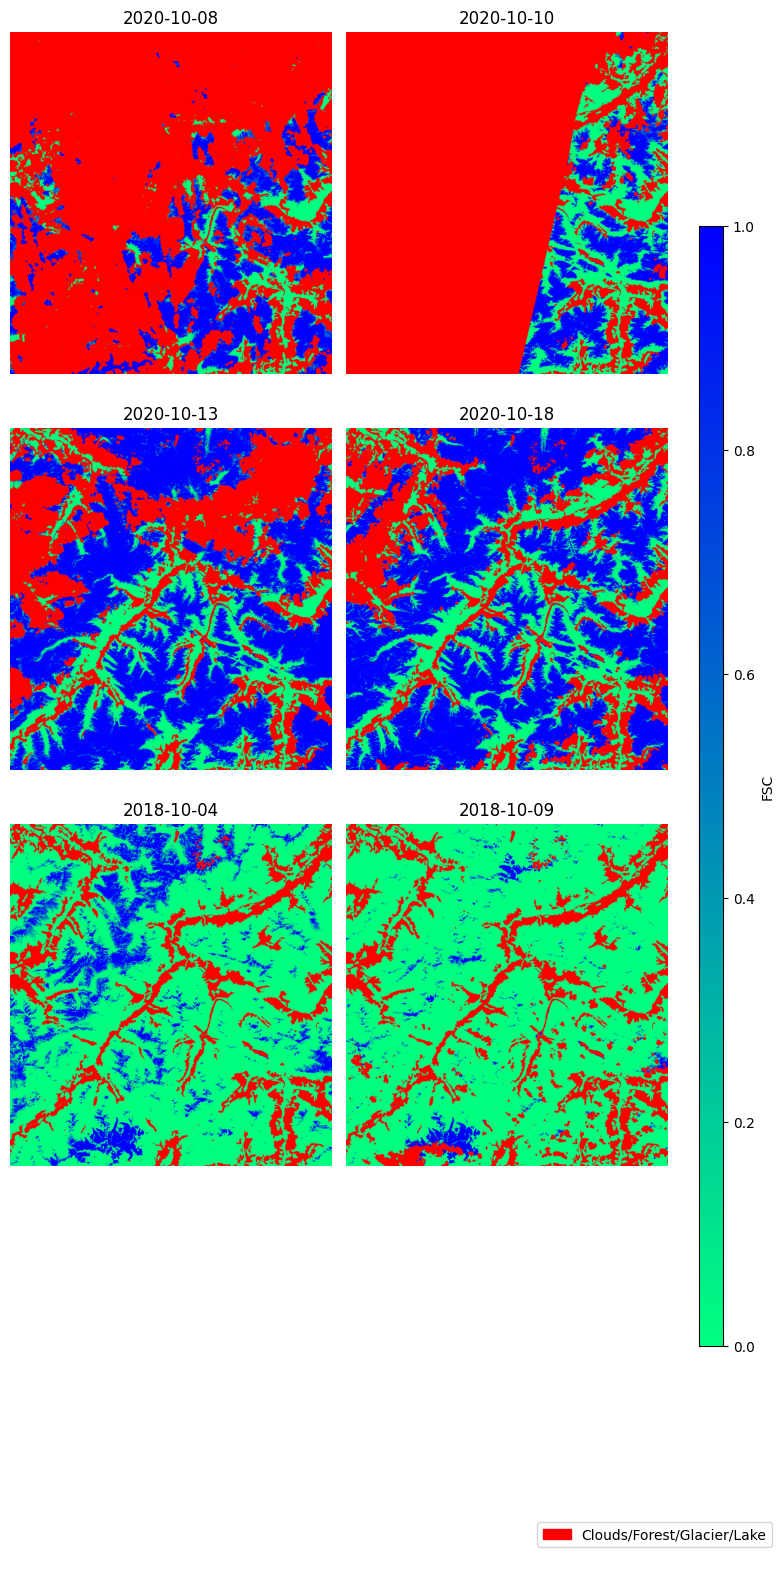

In [5]:
# Example use for ziller 2018-2019
process_fsc_data(
    coords= coords_engadin,
    resolution=20,
    tile_cloud_cover = 50,
    max_nodata_fraction = 0.7,
    selected_dates= [],
    output_folder=r"D:\FSC_results\engadin",
    time_interval=("2018-10-01", "2018-10-15"),
    eval_fsc_scl_mask=eval_fsc_scl_mask,
    glacier_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\GI_5\Gletscher_AOIs.shp",
    lake_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\Seen_AOIs.shp",
    forest_mask_path = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\ses_topo_22_forest_mask_domain_epsg32632.tif"
    )

# C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\engadin

In [ ]:
# Example use for ziller 2018-2019
process_fsc_data(
    coords= coords_nordost,
    resolution=20,
    tile_cloud_cover = 50,
    max_nodata_fraction = 0.7,
    selected_dates= [],
    output_folder=r"D:\FSC_results\nordost",
    time_interval=("2020-10-01", "2020-10-20"),
    eval_fsc_scl_mask=eval_fsc_scl_mask,
    glacier_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\GI_5\Gletscher_AOIs.shp",
    lake_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\Seen_AOIs.shp",
    forest_mask_path = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\ses_topo_22_forest_mask_domain_epsg32632.tif"
    )

In [ ]:
# Example use for ziller 2018-2019
process_fsc_data(
    coords= coords_zentral,
    resolution=20,
    tile_cloud_cover = 50,
    max_nodata_fraction = 0.7,
    selected_dates= [],
    output_folder=r"D:\FSC_results\zentral",
    time_interval=("2020-10-01", "2020-10-20"),
    eval_fsc_scl_mask=eval_fsc_scl_mask,
    glacier_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\GI_5\Gletscher_AOIs.shp",
    lake_shp = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\Seen_AOIs.shp",
    forest_mask_path = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\ses_topo_22_forest_mask_domain_epsg32632.tif"
    )